**ПРОЕКТ:\
"Разработка персонализированных предложений клиентам интернет-магазина"**

**Цель:**\
Разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

**Задачи:**
1) Нужно промаркировать уровень финансовой активности постоянных покупателей. В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».

2) Нужно собрать данные по клиентам по следующим группам:
- Признаки, которые описывают коммуникацию сотрудников компании с клиентом.
- Признаки, которые описывают продуктовое поведение покупателя. Например, какие товары покупает и как часто.
- Признаки, которые описывают покупательское поведение клиента. Например, сколько тратил в магазине.
- Признаки, которые описывают поведение покупателя на сайте. Например, как много страниц просматривает и сколько времени проводит на сайте.

**ПЛАН**
- **Шаг 1.** Установка и импорт библиотек, загрузка данных
1. Загрузить данные.
2. Проверьте, что данные в таблицах соответствуют описанию. Исследованием и объединением данных вы займётесь позже.
- **Шаг 2.** Предобработка данных

Названия столбцов можно оставить кириллическими.

- **Шаг 3.** Исследовательский анализ данных

Провести исследовательский анализ данных каждой таблицы. Отберать клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период. Оформить выводы по результатам шага.

- **Шаг 4.** Объединение таблиц
1. Объединить таблицы market_file.csv, market_money.csv, market_time.csv. Данные о прибыли из файла money.csv при моделировании не понадобятся. 
2. Учесть, что данные о выручке и времени на сайте находятся в одном столбце для всех периодов. В итоговой таблице сделать отдельный столбец для каждого периода.
- **Шаг 5.** Корреляционный анализ

Провести корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования. Сделать выводы о мультиколлинеарности и при необходимости устраните её.

- **Шаг 6.** Использование пайплайнов

Применить все изученные модели. Для этого использовать пайплайны.

1. Во время подготовки данных использовать ColumnTransformer. Количественные и категориальные признаки обработать в пайплайне раздельно. Для кодирования категориальных признаков использовать как минимум два кодировщика, для масштабирования количественных — как минимум два скейлера.
Для каждой модели можно подготовить данные с разным кодированием и масштабированием.
2. Обучить четыре модели: KNeighborsClassifier(), DecisionTreeClassifier() и  SVC(). Для каждой из них подберать как минимум один гиперпараметр. Выберать подходящую для задачи метрику, аргументировать свой выбор. Использовать эту метрику при подборе гиперпараметров.
3. Выбрать лучшую модель, используя заданную метрику. Для этого примените одну из стратегий:
использовать пайплайны и инструменты подбора гиперпараметров для каждой модели отдельно, чтобы выбрать лучшую модель самостоятельно;
использовать один общий пайплайн для всех моделей и инструмент подбора гиперпараметров, который вернёт лучшую модель.
- **Шаг 7.** Анализ важности признаков
1. Оценить важность признаков для лучшей модели и построить график важности с помощью метода SHAP. 
2. Сделать выводы о значимости признаков:\
какие признаки мало значимы для модели;\
какие признаки сильнее всего влияют на целевой признак;\
как можно использовать эти наблюдения при моделировании и принятии бизнес-решений.
- **Шаг 8.** Сегментация покупателей
1. Выполнить сегментацию покупателей. Использовать результаты моделирования и данные о прибыльности покупателей.
2. Выбрать группу покупателей и предложить, как увеличить её покупательскую активность: 
Провести графическое и аналитическое исследование группы покупателей.
Сделать предложения по работе с сегментом для увеличения покупательской активности.
3. Сделать выводы о сегментах:\
какой сегмент взяли для дополнительного исследования,\
какие предложения сделали и почему.
- **Шаг 9.** Общий вывод
Сделать общий вывод:\
описать задачу;\
описать исходные данные и проведённую предобработку;\
написать, что сделали для поиска лучшей модели;\
указать лучшую модель;\
добавить выводы и дополнительные предложения для выбранного сегмента покупателей.

**Шаг 1.** Установка и импорт библиотек, загрузка данных

In [6]:
#Установка библиотек
!pip install imblearn
!pip install -q phik
!pip install -Uq scikit-learn
!pip install -q shap


#Импорт библиотек

#Библиотеки для работы с данными и исследовательскому анализу
import pandas as pd
import numpy as np
import phik
from scipy import stats as st

#Визуализация:
import matplotlib.pyplot as plt
import seaborn as sns

#Разработка моделей:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

#Метрики:
import shap
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, f1_score

In [7]:
import os
print(os.getcwd())

C:\Users\serge\Downloads


In [8]:
#Загрузка и просмотр market_file.csv
market_df = pd.read_csv('market_file.csv')
market_df.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [9]:
market_df.shape

(1300, 13)

In [10]:
#Загрузка и просмотр market_money.csv
market_money_df = pd.read_csv('market_money.csv')
market_money_df.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [11]:
market_money_df.shape

(3900, 3)

In [12]:
#Загрузка и просмотр market_time.csv
market_time_df = pd.read_csv('market_time.csv', sep=',')
market_time_df.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [13]:
market_time_df.shape

(2600, 3)

In [14]:
#Загрузка и просмотр money.csv
money_df = pd.read_csv('money.csv', sep=';', decimal=',')
money_df.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [15]:
money_df.shape

(1300, 2)

**Выводы Шага 1:**\
Данные успешно загружены, просмотрены, предварительно намечены задачи предобработки.

**Шаг 2.** Предобработка данных

In [16]:
#Переименование столбцов (кириллические названия, без "змеиного" шрифта, без заглавных букв):
market_df.columns = [
    'id',
    'покупательская активность',
    'тип сервиса',
    'разрешить сообщать',
    'маркет актив 6 мес',
    'маркет актив тек мес',
    'длительность',
    'акционные покупки',
    'популярная категория',
    'средний просмотр категорий за визит',
    'неоплаченные продукты штук квартал',
    'ошибка сервиса',
    'страниц за визит'
    ]
market_money_df.columns = [
    'id',
    'период',
    'выручка'
    ]
market_time_df.columns = [
    'id',
    'период',
    'минут'
    ]
money_df.columns = [
    'id',
    'прибыль'
    ]

In [17]:
#Проверка необходимости изменения типов данных, а также наличия пропусков:
market_df.info()
print('________________________________________')
market_money_df.info()
print('________________________________________')
market_time_df.info()
print('________________________________________')
money_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская активность            1300 non-null   object 
 2   тип сервиса                          1300 non-null   object 
 3   разрешить сообщать                   1300 non-null   object 
 4   маркет актив 6 мес                   1300 non-null   float64
 5   маркет актив тек мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные покупки                    1300 non-null   float64
 8   популярная категория                 1300 non-null   object 
 9   средний просмотр категорий за визит  1300 non-null   int64  
 10  неоплаченные продукты штук квартал   1300 non-null   int64  
 11  ошибка сервиса                

Типы данных во всех датафреймах корректны и не требуют преобразований. Пропусков не найдено.

In [18]:
#Проверка неявных дубликатов market_df
for cat in market_df.select_dtypes('object').columns:
    print('\n', cat)
    for value in market_df[cat].value_counts().index.tolist():
        print(f'{value} (кол-во пробелов: {value.count(" ")})') #проверка наличия пробелов


 покупательская активность
Прежний уровень (кол-во пробелов: 1)
Снизилась (кол-во пробелов: 0)

 тип сервиса
стандарт (кол-во пробелов: 0)
премиум (кол-во пробелов: 0)
стандартт (кол-во пробелов: 0)

 разрешить сообщать
да (кол-во пробелов: 0)
нет (кол-во пробелов: 0)

 популярная категория
Товары для детей (кол-во пробелов: 2)
Домашний текстиль (кол-во пробелов: 1)
Косметика и аксесуары (кол-во пробелов: 2)
Техника для красоты и здоровья (кол-во пробелов: 4)
Мелкая бытовая техника и электроника (кол-во пробелов: 4)
Кухонная посуда (кол-во пробелов: 1)


In [19]:
#Удаление неявных дубликатов market_df и корректировка значений:
for cat in market_df.select_dtypes('object').columns:
    market_df[cat] = market_df[cat].apply(lambda x : x.lower())
market_df['тип сервиса'] = market_df['тип сервиса'].replace('стандартт', 'стандарт')

In [20]:
#Проверка изменений market_df
for cat in market_df.select_dtypes('object').columns:
    print('\n', cat)
    for value in market_df[cat].value_counts().index.tolist():
        print(f'{value} (число символов: {len(value)})') #проверка наличия пробелов


 покупательская активность
прежний уровень (число символов: 15)
снизилась (число символов: 9)

 тип сервиса
стандарт (число символов: 8)
премиум (число символов: 7)

 разрешить сообщать
да (число символов: 2)
нет (число символов: 3)

 популярная категория
товары для детей (число символов: 16)
домашний текстиль (число символов: 17)
косметика и аксесуары (число символов: 21)
техника для красоты и здоровья (число символов: 30)
мелкая бытовая техника и электроника (число символов: 36)
кухонная посуда (число символов: 15)


In [21]:
#Проверка неявных дубликатов market_money_df
for cat in market_money_df.select_dtypes('object').columns:
    print('\n', cat)
    for value in market_money_df[cat].value_counts().index.tolist():
        print(f'{value} (кол-во пробелов: {value.count(" ")})') #проверка наличия пробелов


 период
текущий_месяц (кол-во пробелов: 0)
препредыдущий_месяц (кол-во пробелов: 0)
предыдущий_месяц (кол-во пробелов: 0)


In [22]:
#Удаление неявных дубликатов market_money_df и корректировка значений:
market_money_df['период'] = market_money_df['период'].replace({
    'текущий_месяц' : 'текущий месяц',
    'препредыдущий_месяц' : 'предпредыдущий месяц',
    'предыдущий_месяц' : 'предыдущий месяц'
    })

In [23]:
#Проверка изменений market_money_df
for cat in market_money_df.select_dtypes('object').columns:
    print('\n', cat)
    for value in market_money_df[cat].value_counts().index.tolist():
        print(f'{value} (кол-во пробелов: {value.count(" ")})') #проверка наличия пробелов


 период
предыдущий месяц (кол-во пробелов: 1)
текущий месяц (кол-во пробелов: 1)
предпредыдущий месяц (кол-во пробелов: 1)


In [24]:
#Проверка неявных дубликатов market_time_df
for cat in market_time_df.select_dtypes('object').columns:
    print('\n', cat)
    for value in market_time_df[cat].value_counts().index.tolist():
        print(f'{value} (кол-во пробелов: {value.count(" ")})') #проверка наличия пробелов


 период
предыдцщий_месяц (кол-во пробелов: 0)
текущий_месяц (кол-во пробелов: 0)


In [25]:
#Удаление неявных дубликатов market_time_df и корректировка значений:
market_time_df['период'] = market_time_df['период'].replace({
    'текущий_месяц' : 'текущий месяц',
    'предыдцщий_месяц' : 'предыдущий месяц'
    })

In [26]:
#Проверка изменений market_time_df
for cat in market_time_df.select_dtypes('object').columns:
    print('\n', cat)
    for value in market_time_df[cat].value_counts().index.tolist():
        print(f'{value} (кол-во пробелов: {value.count(" ")})') #проверка наличия пробелов


 период
предыдущий месяц (кол-во пробелов: 1)
текущий месяц (кол-во пробелов: 1)


In [27]:
#Проверка явных дубликатов:
print(market_df.duplicated().sum())
print(market_money_df.duplicated().sum())
print(market_time_df.duplicated().sum())
print(money_df.duplicated().sum())

0
0
0
0


In [28]:
#Удаление явных дубликатов:
market_money_df = market_money_df.drop_duplicates()

In [29]:
#Проверка удаления дубликатов:
print(market_df.duplicated().sum())
print(market_money_df.duplicated().sum())
print(market_time_df.duplicated().sum())
print(money_df.duplicated().sum())

0
0
0
0


**Вывод Шага 2:** Данные предобработаны, приведены к однообразному форматированию, дубликаты удалены, пропуски проверены.

**Шаг 3.** Исследовательский анализ данных

In [30]:
#Создание функции построения гистограмм количественных признаков:
def hist_plot(data, col):
    plt.figure(figsize=(12, 8))
    plt.hist(
        data[col],
        bins=100,
        color='skyblue',
        edgecolor='navy'
        )
    plt.axvline(
        x=data[col].median(),
        color='red',
        linestyle='solid',
        label='Медиана'
        )
    plt.axvline(
        x=data[col].mean(),
        color='red',
        linestyle='dashed',
        label='Среднее'
        )
    plt.title(col)
    plt.ylabel('Количество')
    plt.xlabel(col)
    plt.legend()
    plt.grid()
    plt.show()

In [31]:
#Создание функции построения pie-графика категориальных признаков:
def pie_plot(data, col):
    plt.figure(figsize=(8, 8))
    plt.pie(
        x=data[col].value_counts(),
        labels=data[col].value_counts().index.tolist(),
        shadow=True,
        autopct='%1.1f%%',
        )
    plt.title(col)
    plt.show()

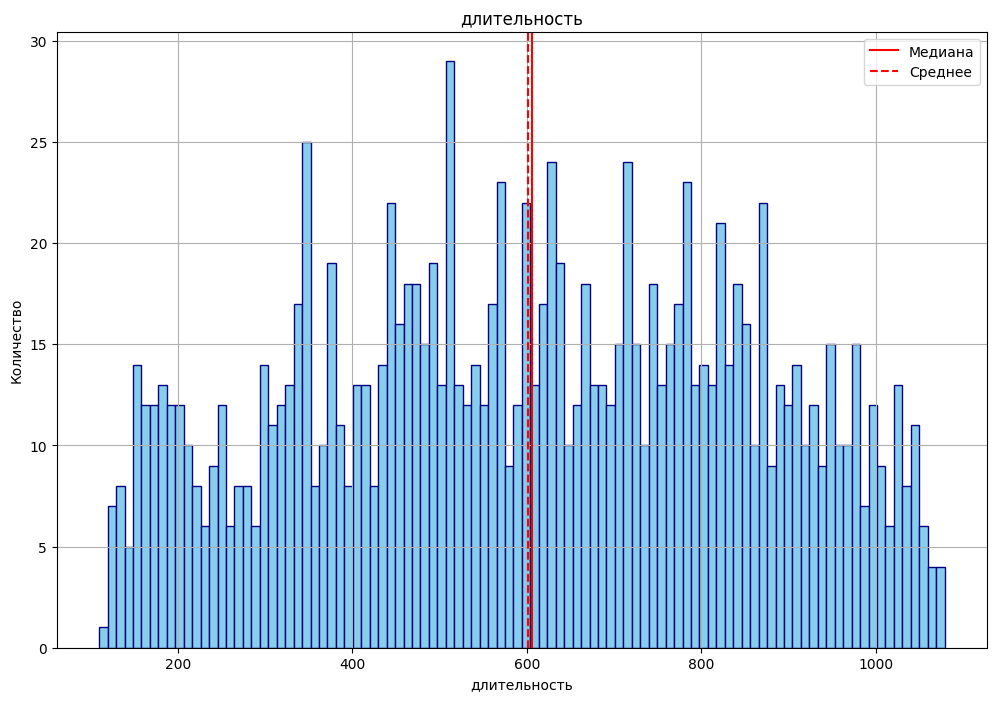

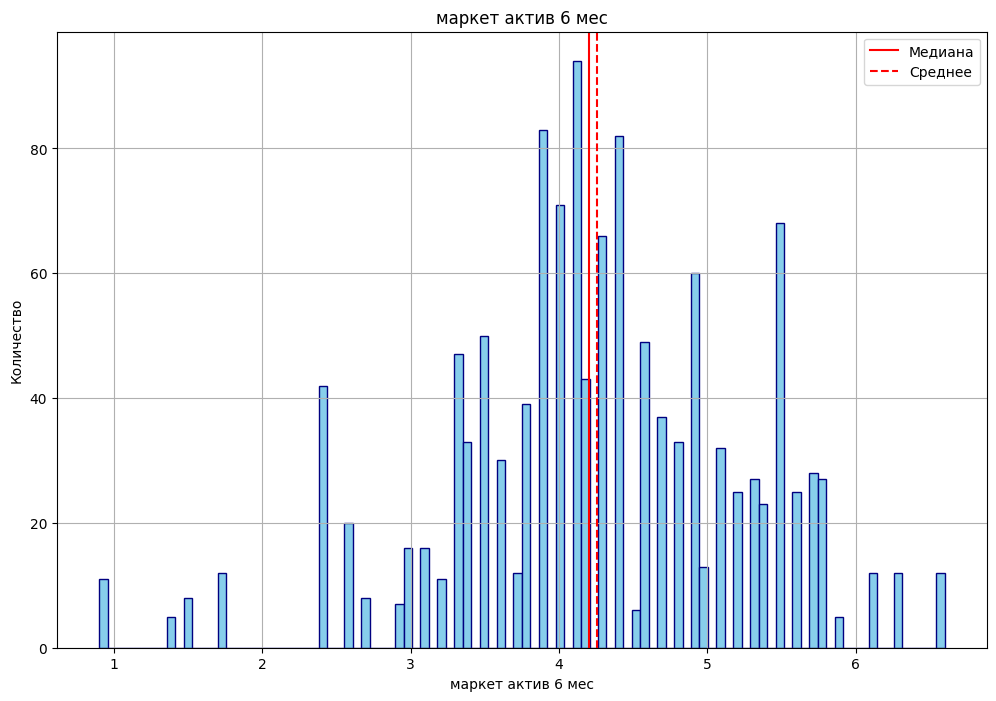

In [32]:
#Визуализация количественных признаков market_df:
hist_plot(market_df, 'длительность')
hist_plot(market_df, 'маркет актив 6 мес')

In [33]:
market_df.select_dtypes('int64', 'float64').drop(['id', 'длительность'], axis=1).columns.tolist()

['маркет актив тек мес',
 'средний просмотр категорий за визит',
 'неоплаченные продукты штук квартал',
 'ошибка сервиса',
 'страниц за визит']

C:\Users\serge\anaconda3\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


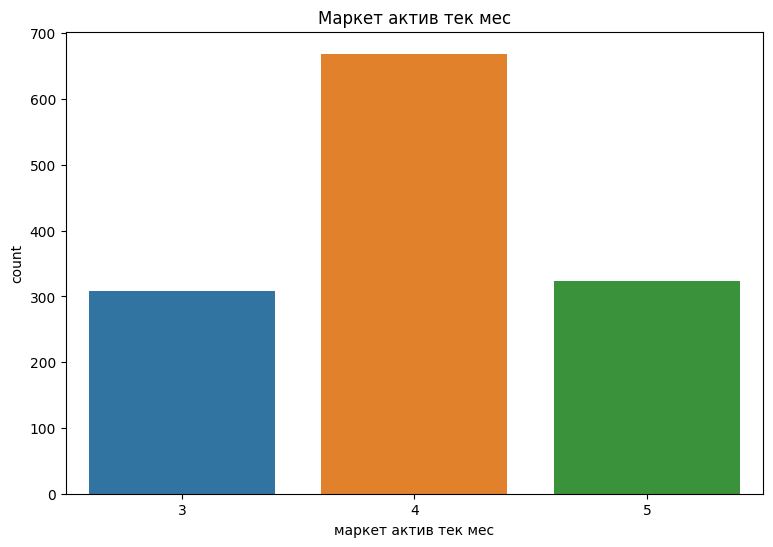

In [34]:
#Визуализация дискретных признаков market_df :
plt.figure(figsize=(9, 6))
sns.countplot(market_df['маркет актив тек мес'])
plt.title('Маркет актив тек мес')
plt.show()

C:\Users\serge\anaconda3\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


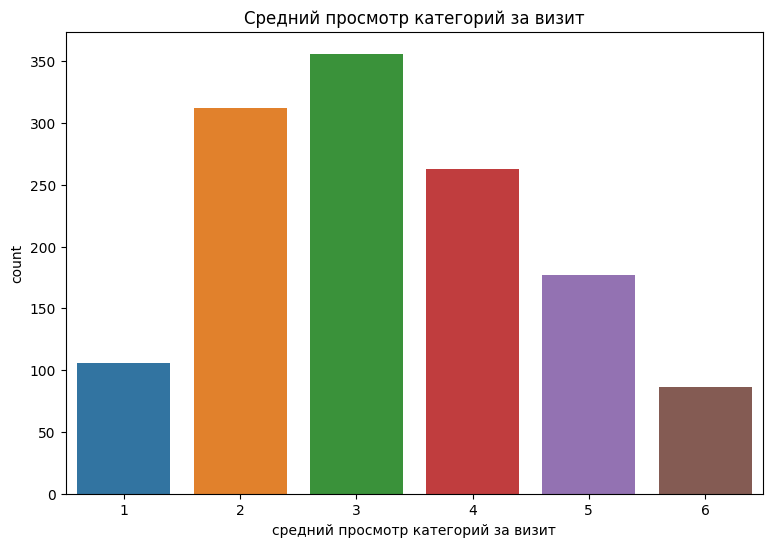

In [35]:
plt.figure(figsize=(9, 6))
sns.countplot(market_df['средний просмотр категорий за визит'])
plt.title('Средний просмотр категорий за визит')
plt.show()

C:\Users\serge\anaconda3\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


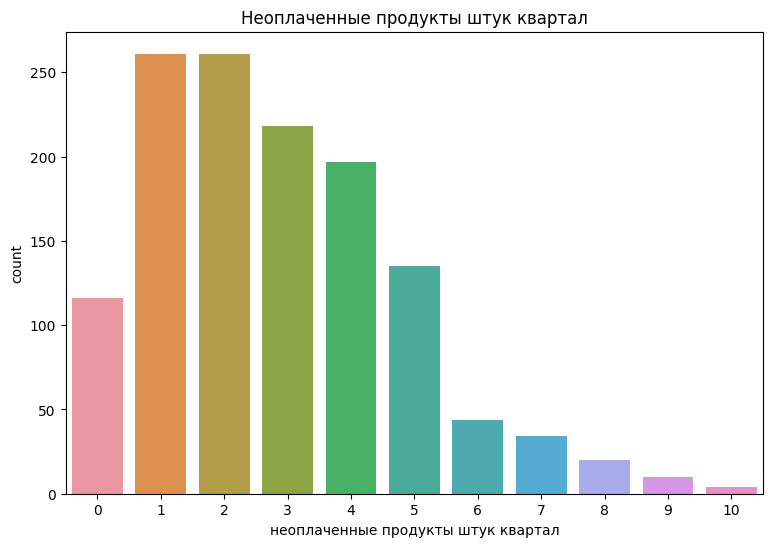

In [36]:
plt.figure(figsize=(9, 6))
sns.countplot(market_df['неоплаченные продукты штук квартал'])
plt.title('Неоплаченные продукты штук квартал')
plt.show()

C:\Users\serge\anaconda3\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


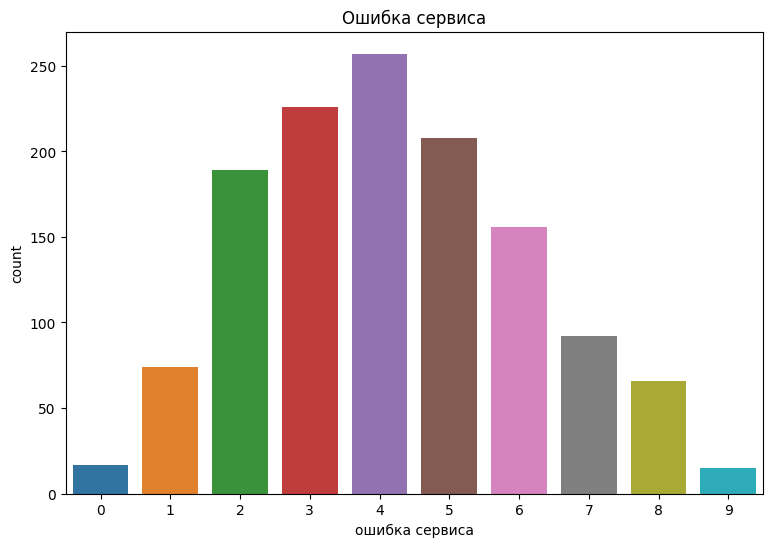

In [37]:
plt.figure(figsize=(9, 6))
sns.countplot(market_df['ошибка сервиса'])
plt.title('Ошибка сервиса')
plt.show()

C:\Users\serge\anaconda3\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


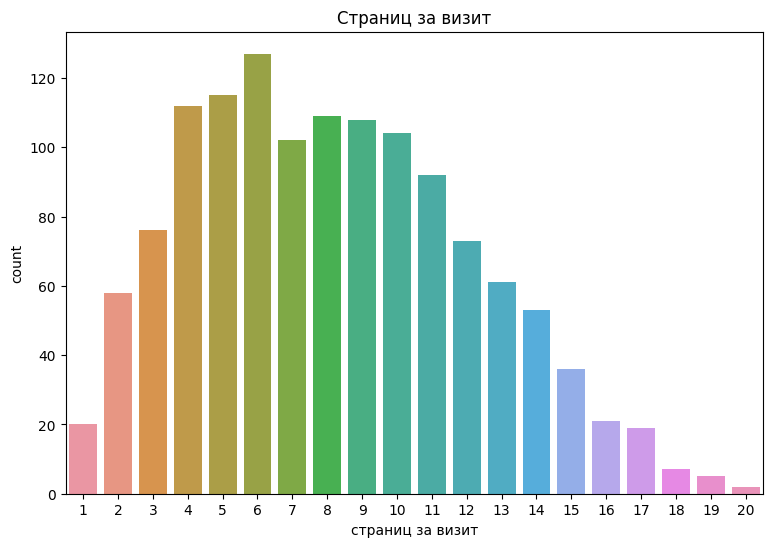

In [38]:
plt.figure(figsize=(9, 6))
sns.countplot(market_df['страниц за визит'])
plt.title('Cтраниц за визит')
plt.show()

In [39]:
#Описательная статистика количественных признаков market_df:
for col in market_df.select_dtypes('int64', 'float64').drop('id', axis=1).columns:
    print(market_df[col].describe())
    print('________________________________________')

count    1300.000000
mean        4.011538
std         0.696868
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: маркет актив тек мес, dtype: float64
________________________________________
count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: длительность, dtype: float64
________________________________________
count    1300.00000
mean        3.27000
std         1.35535
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max         6.00000
Name: средний просмотр категорий за визит, dtype: float64
________________________________________
count    1300.000000
mean        2.840000
std         1.971451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: неоплаченные продукты штук квартал, dtype: float64
____________________

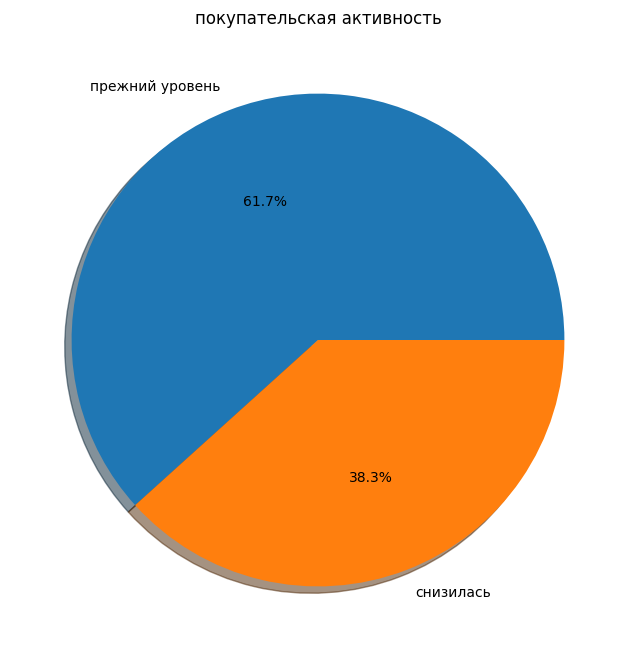

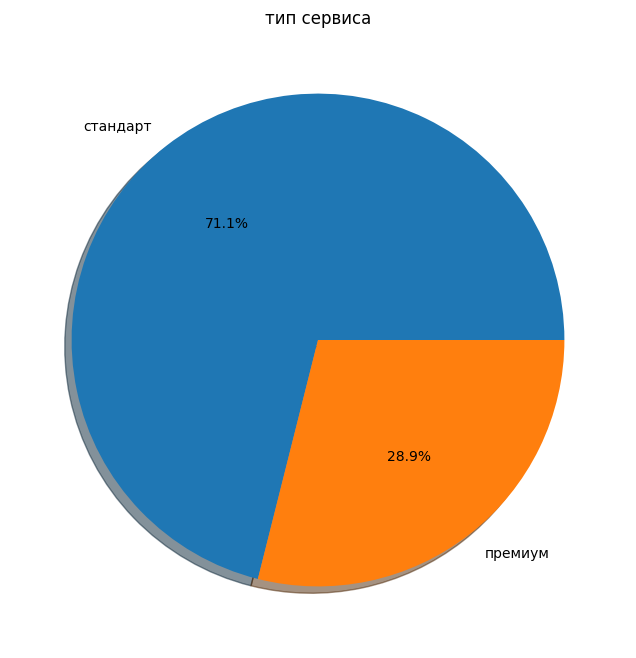

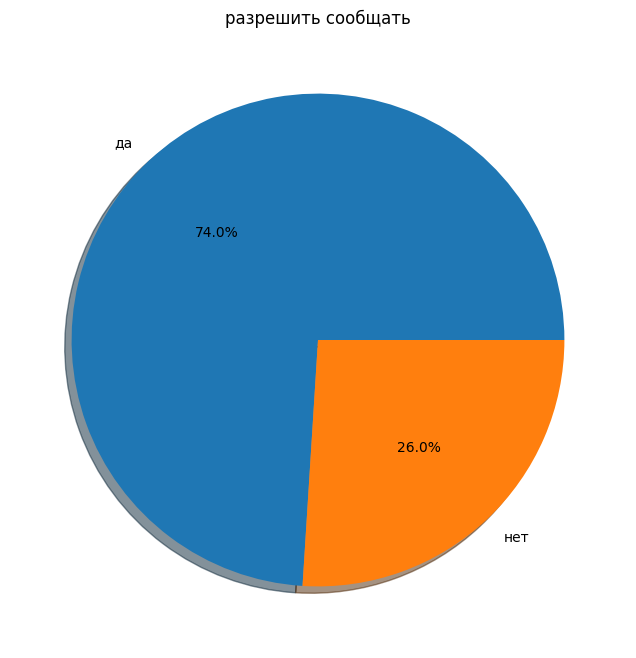

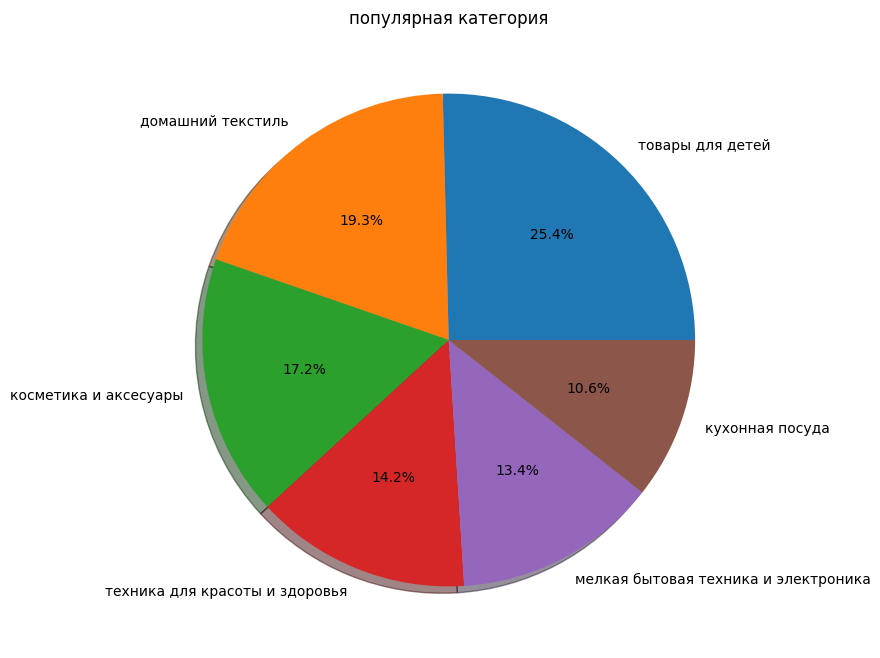

In [40]:
#Визуализация категориальных признаков market_df:
for col in market_df.select_dtypes('object').columns:
    pie_plot(market_df, col)

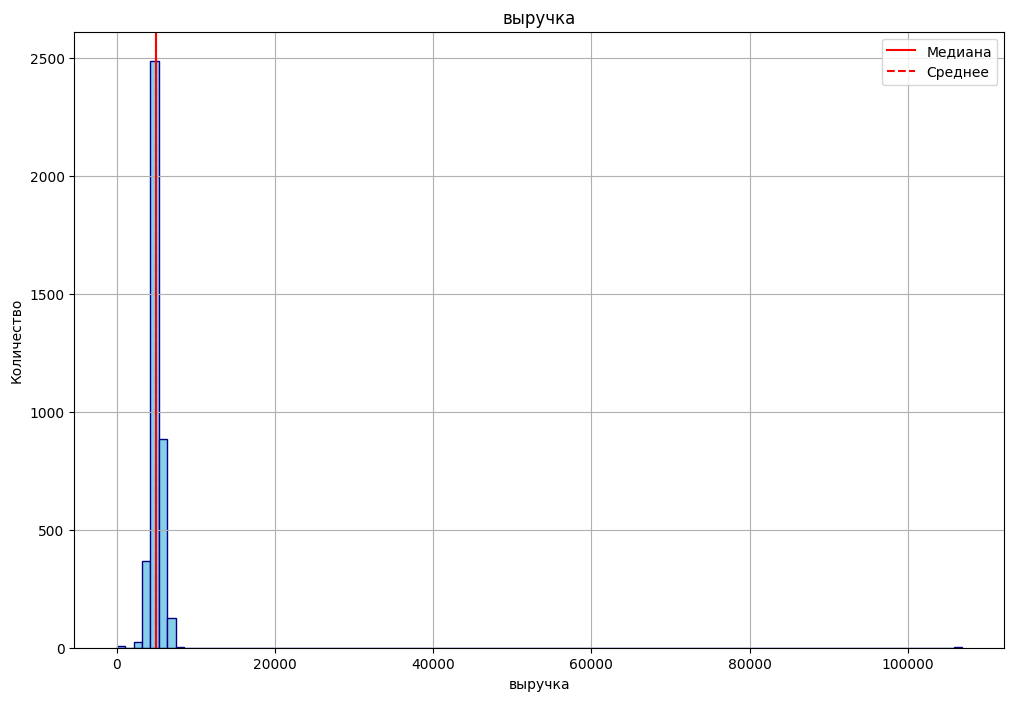

In [41]:
#Визуализация количественных признаков market_money_df:
for col in market_money_df.select_dtypes('float64').columns:
    hist_plot(market_money_df, col)

In [42]:
#Описательная статистика количественных признаков market_df:
for col in market_money_df.select_dtypes('float64').columns:
    print(market_money_df[col].describe())

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: выручка, dtype: float64


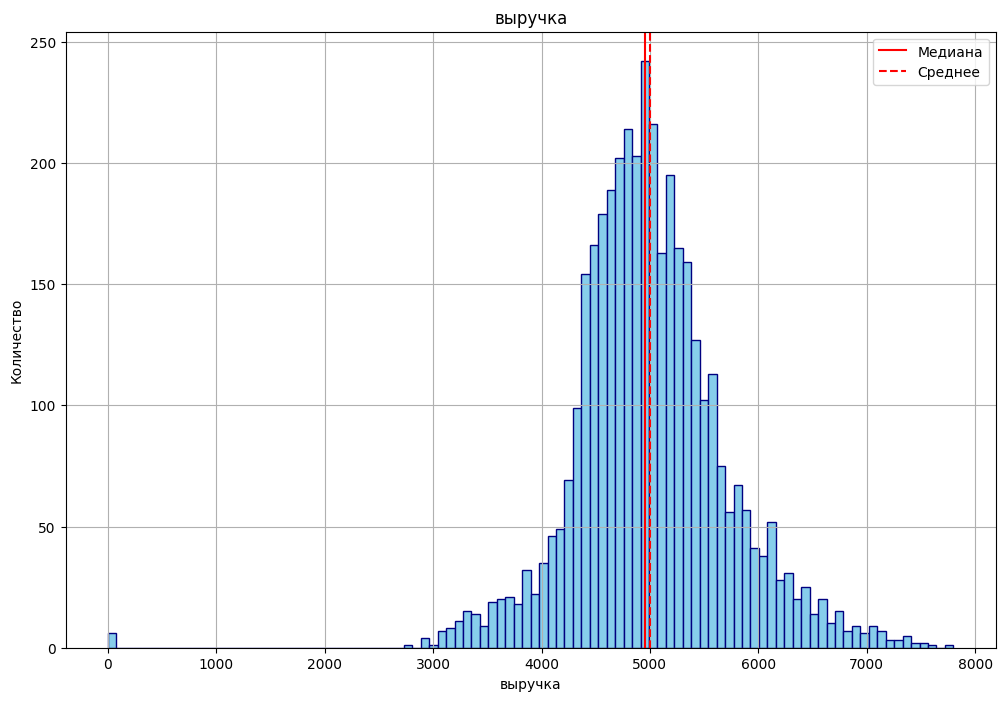

In [43]:
#Удаление аномальных значений в market_money_df:
market_money_df = market_money_df[market_money_df['выручка'] != market_money_df['выручка'].max()]
#Визуализация количественных признаков market_money_df:
for col in market_money_df.select_dtypes('float64').columns:
    hist_plot(market_money_df, col)

In [44]:
#Новая описательная статистика количественных признаков market_df:
for col in market_money_df.select_dtypes('float64').columns:
    print(market_money_df[col].describe())

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
Name: выручка, dtype: float64


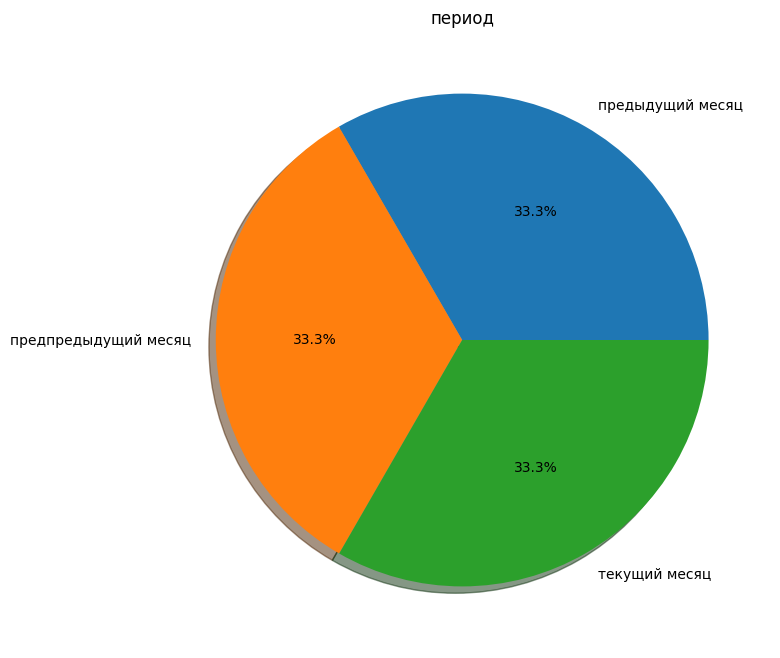

In [45]:
#Визуализация категориальных признаков market_money_df:
for col in market_money_df.select_dtypes('object').columns:
    pie_plot(market_money_df, col)

C:\Users\serge\anaconda3\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


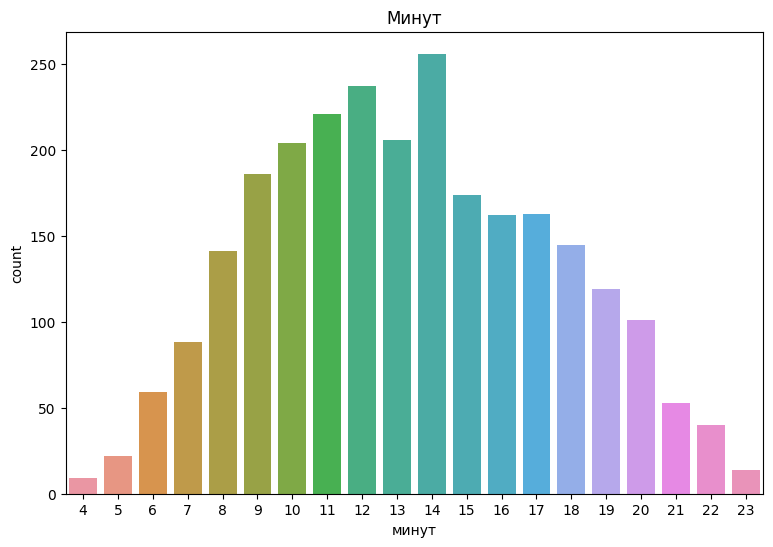

In [46]:
#Визуализация категориального признака "минут" market__time_df:
plt.figure(figsize=(9, 6))
sns.countplot(market_time_df['минут'])
plt.title('Минут')
plt.show()

In [47]:
#Описательная статистика количественных признаков market_df:
for col in market_time_df.select_dtypes('int64', 'float64').drop('id', axis=1).columns:
    print(market_time_df[col].describe())

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64


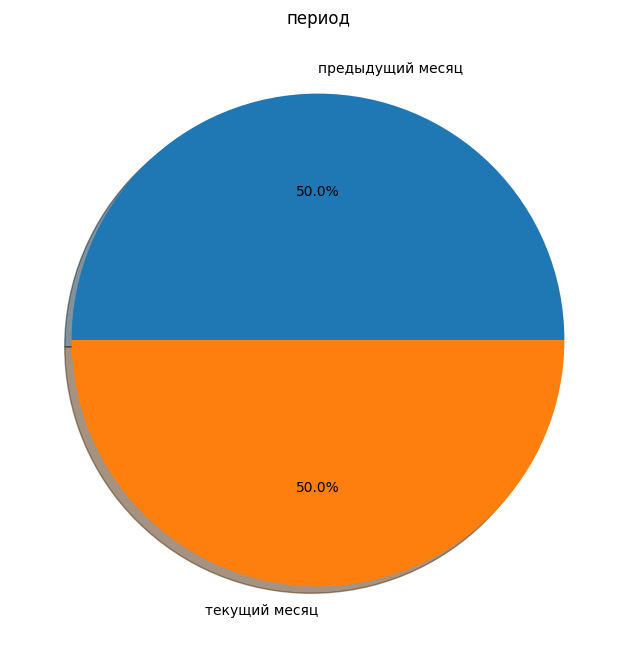

In [48]:
#Визуализация категориальных признаков market_df:
for col in market_time_df.select_dtypes('object').columns:
    pie_plot(market_time_df, col)

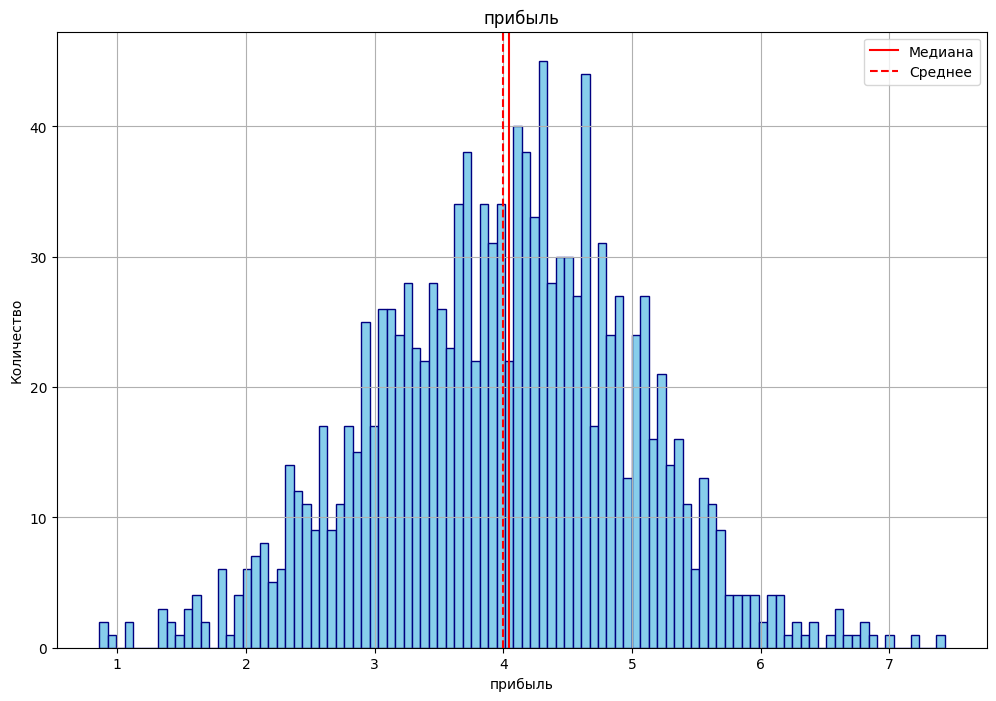

In [49]:
#Визуализация количественных признаков market_df:
for col in money_df.select_dtypes('float64').columns:
    hist_plot(money_df, col)

In [50]:
#Описательная статистика количественных признаков market_df:
for col in money_df.select_dtypes('float64').columns:
    print(money_df[col].describe())

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64


In [51]:
#Агрегирование пользователей по произведению выручки каждого месяца:
market_money_id_df = market_money_df.pivot_table(index='id', values='выручка', columns='период', aggfunc='sum')
market_money_id_df.columns = ['выручка за предпредыдущий месяц', 'выручка за предыдущий месяц', 'выручка за текущий месяц']
print(market_money_id_df.shape)

(1300, 3)


In [52]:
#Проверка результатов агрегирования:
market_money_id_df.head(10)

,выручка за предпредыдущий месяц,выручка за предыдущий месяц,выручка за текущий месяц
id,,,
215348,0.0,0.0,3293.1
215349,4472.0,5216.0,4971.6
215350,4826.0,5457.5,5058.4
215351,4793.0,6158.0,6610.4
215352,4594.0,5807.5,5872.5
215353,5124.0,4738.5,5388.5
215354,4503.0,5685.0,5869.6
215355,4749.0,3263.0,3772.6
215356,4433.0,4146.5,4566.4


In [53]:
#Отбор пользователей с покупательской активностью на протяжении всех трёх месяцев:
market_money_id_df = market_money_id_df[
    (market_money_id_df['выручка за предпредыдущий месяц'] *\
    market_money_id_df['выручка за предпредыдущий месяц'] *\
    market_money_id_df['выручка за текущий месяц']) > 0]
print(market_money_id_df.shape)

(1296, 3)


In [54]:
#Проверка отобранного датасета:
market_money_id_df.head(10)

,выручка за предпредыдущий месяц,выручка за предыдущий месяц,выручка за текущий месяц
id,,,
215349,4472.0,5216.0,4971.6
215350,4826.0,5457.5,5058.4
215351,4793.0,6158.0,6610.4
215352,4594.0,5807.5,5872.5
215353,5124.0,4738.5,5388.5
215354,4503.0,5685.0,5869.6
215355,4749.0,3263.0,3772.6
215356,4433.0,4146.5,4566.4
215358,4727.0,3488.0,4209.5


**Выводы Шага 3:** Проведен исследовательский анализ данных, визуализированы количественные и категориальные признаки, получена описательная статистика. В большинстве случаев распределение количестенных признаков близко к нормальному. Аномальные значения удалены. Отобраны пользователи с покупательской активностью на протяжении всех трёх месяцев. В целевом признаке наблюдается дисбаланс классов в соотношении 1 к 2.

**Шаг 4.** Объединение таблиц

In [55]:
#
print(market_df.shape)
print(market_money_id_df.shape)
print(market_time_df.shape)

(1300, 13)
(1296, 3)
(2600, 3)


In [56]:
#Агрегируем данные датасета market_time_df по id :
market_time_df = market_time_df.pivot_table(index='id', columns='период')
market_time_df.columns = ['минут в предыдущем месяце', 'минут в текущем месяце']
print(market_money_id_df.shape)

(1296, 3)


In [57]:
#Проверка результатов агрегации:
market_time_df.head(10)

,минут в предыдущем месяце,минут в текущем месяце
id,,
215348,13,14
215349,12,10
215350,8,13
215351,11,13
215352,8,11
215353,10,10
215354,11,12
215355,12,10
215356,6,7


In [58]:
#Объединение датасетов
df = market_df.join(market_money_id_df, on='id', how='right').join(market_time_df, on='id', how='left')
#Проверка размерности итогового датасета
print(df.shape)

(1296, 18)


In [59]:
df.head(10)

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит,выручка за предпредыдущий месяц,выручка за предыдущий месяц,выручка за текущий месяц,минут в предыдущем месяце,минут в текущем месяце
1,215349,снизилась,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
2,215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
3,215351,снизилась,стандарт,да,3.2,5,896,0.99,товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
4,215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11
5,215353,снизилась,стандарт,да,3.3,4,762,0.26,домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10
6,215354,снизилась,стандарт,да,5.1,3,431,0.23,косметика и аксесуары,2,3,7,2,4503.0,5685.0,5869.6,11,12
7,215355,снизилась,стандарт,нет,4.7,4,284,0.17,товары для детей,5,1,6,4,4749.0,3263.0,3772.6,12,10
8,215356,снизилась,стандарт,да,4.2,4,192,0.14,косметика и аксесуары,2,2,1,3,4433.0,4146.5,4566.4,6,7
10,215358,снизилась,стандарт,да,4.7,4,450,0.13,домашний текстиль,4,2,6,4,4727.0,3488.0,4209.5,14,10
12,215360,снизилась,премиум,да,3.9,3,623,0.35,кухонная посуда,3,1,4,7,5555.0,5304.5,5834.9,9,6


**Выводы Шага 4:** Датасеты успешно объединены, размерности сверены.

**Шаг 5.** Корреляционный анализ

In [60]:
#Преобразование столбца id в индекс:
df = df.set_index('id')
print(df.shape)

(1296, 17)


In [61]:
df.columns

Index(['покупательская активность', 'тип сервиса', 'разрешить сообщать',
       'маркет актив 6 мес', 'маркет актив тек мес', 'длительность',
       'акционные покупки', 'популярная категория',
       'средний просмотр категорий за визит',
       'неоплаченные продукты штук квартал', 'ошибка сервиса',
       'страниц за визит', 'выручка за предпредыдущий месяц',
       'выручка за предыдущий месяц', 'выручка за текущий месяц',
       'минут в предыдущем месяце', 'минут в текущем месяце'],
      dtype='object')

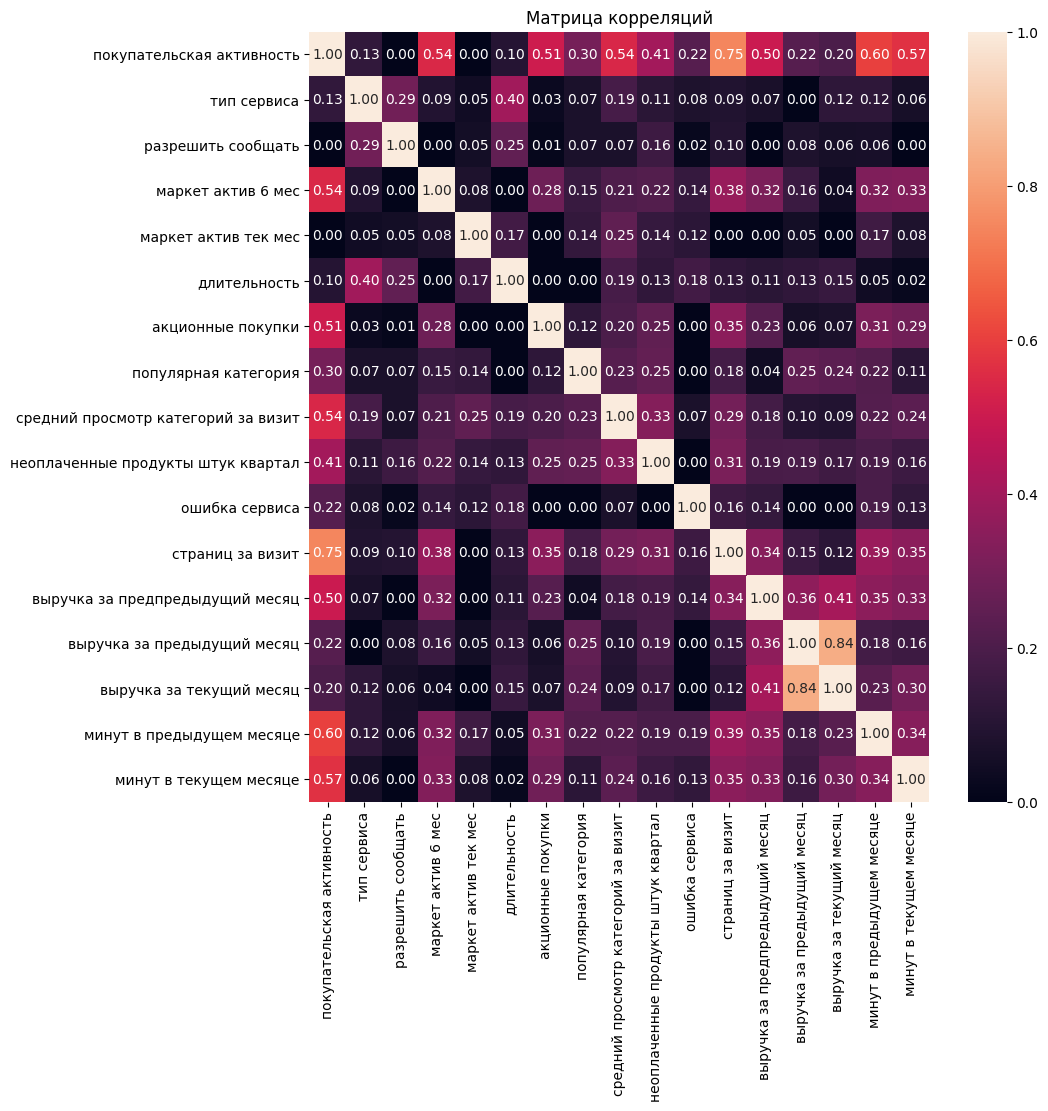

In [62]:
#Построение матрицы корреляций количественных признаков:
plt.figure(figsize=(10, 10))
sns.heatmap(df.phik_matrix(interval_cols=[
            'маркет актив 6 мес',
            'длительность',
            'акционные покупки',
            'выручка за предпредыдущий месяц',
            'выручка за предыдущий месяц',
            'выручка за текущий месяц'
            ]
        ),
    annot=True, fmt='.2f'
    )
plt.title('Матрица корреляций')
plt.show()

Признаки помесячных выручек **мультиколлинеарны**, для устранения этого можно ввести новый признак на основе мультиколлинеарных, во-первых, **средний коэффициент роста выручки**:
- ((выручка в текущем месяце) - (выручка в предыдущем месяце)) \ (выручка в предыдущем месяце) = (коэф. выручки в текущем месяце)
- ((выручка в предыдущем месяце) - (выручка в предпредыдущем месяце)) \ (выручка в предпредыдущем месяце) = (коэф. выручки в педыдущем месяце)
- ((коэф. выручки в текущем месяце) + (коэф. выручки в педыдущем месяце)) \ 2 = (средний коэф. роста выручки)

во-вторых, чтобы сохранить информацию о масштабе покупок разных пользователей (пользователи с одинаковым коэффициентом роста выручки могут тратить абсолютно разное количество денег на покупки), помесячную выручку необходимо обобщить **средней выручкой** за весь рассматриваемый период.

In [63]:
#Cоздание новых признаков в df :
revenue_coef1 = (df['выручка за текущий месяц'] - df['выручка за предыдущий месяц']) / df['выручка за предыдущий месяц']
revenue_coef2 = (df['выручка за предыдущий месяц'] - df['выручка за предпредыдущий месяц']) / df['выручка за предпредыдущий месяц']
df['коэффициент роста выручки'] = (((revenue_coef1 + revenue_coef2)) / 2).round(4)

df['средняя выручка'] = (
    (df['выручка за предпредыдущий месяц'] + df['выручка за предыдущий месяц'] + df['выручка за текущий месяц']) / 3
    ).round(4)

In [64]:
df.sample(10)

,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит,выручка за предпредыдущий месяц,выручка за предыдущий месяц,выручка за текущий месяц,минут в предыдущем месяце,минут в текущем месяце,коэффициент роста выручки,средняя выручка
id,,,,,,,,,,,,,,,,,,,
216215,прежний уровень,стандарт,да,3.4,3,603,0.15,мелкая бытовая техника и электроника,3,0,3,9,4850.0,4788.5,4865.2,14,14,0.0017,4834.5667
216289,прежний уровень,стандарт,да,5.4,3,512,0.29,домашний текстиль,3,4,4,10,5059.0,5716.0,6415.4,12,12,0.1261,5730.1333
216585,прежний уровень,стандарт,нет,5.9,3,134,0.25,товары для детей,4,4,2,9,4661.0,3853.0,4683.7,16,16,0.0211,4399.2333
216522,прежний уровень,стандарт,да,5.5,4,969,0.12,домашний текстиль,5,2,2,11,4449.0,4708.5,5063.4,14,22,0.0669,4740.3000
215798,снизилась,стандарт,да,4.3,5,623,0.24,мелкая бытовая техника и электроника,2,2,8,12,4883.0,4656.5,4590.2,15,16,-0.0303,4709.9000
215990,прежний уровень,стандарт,да,4.7,4,826,0.16,техника для красоты и здоровья,2,2,6,12,4997.0,4966.0,5123.3,13,16,0.0127,5028.7667
216032,прежний уровень,стандарт,нет,5.5,4,628,0.33,товары для детей,3,1,4,8,5168.0,5651.0,5362.4,19,19,0.0212,5393.8000
215354,снизилась,стандарт,да,5.1,3,431,0.23,косметика и аксесуары,2,3,7,2,4503.0,5685.0,5869.6,11,12,0.1475,5352.5333
216043,прежний уровень,стандарт,да,4.0,4,577,0.25,товары для детей,3,3,2,14,4797.0,4488.0,4885.8,17,12,0.0121,4723.6000


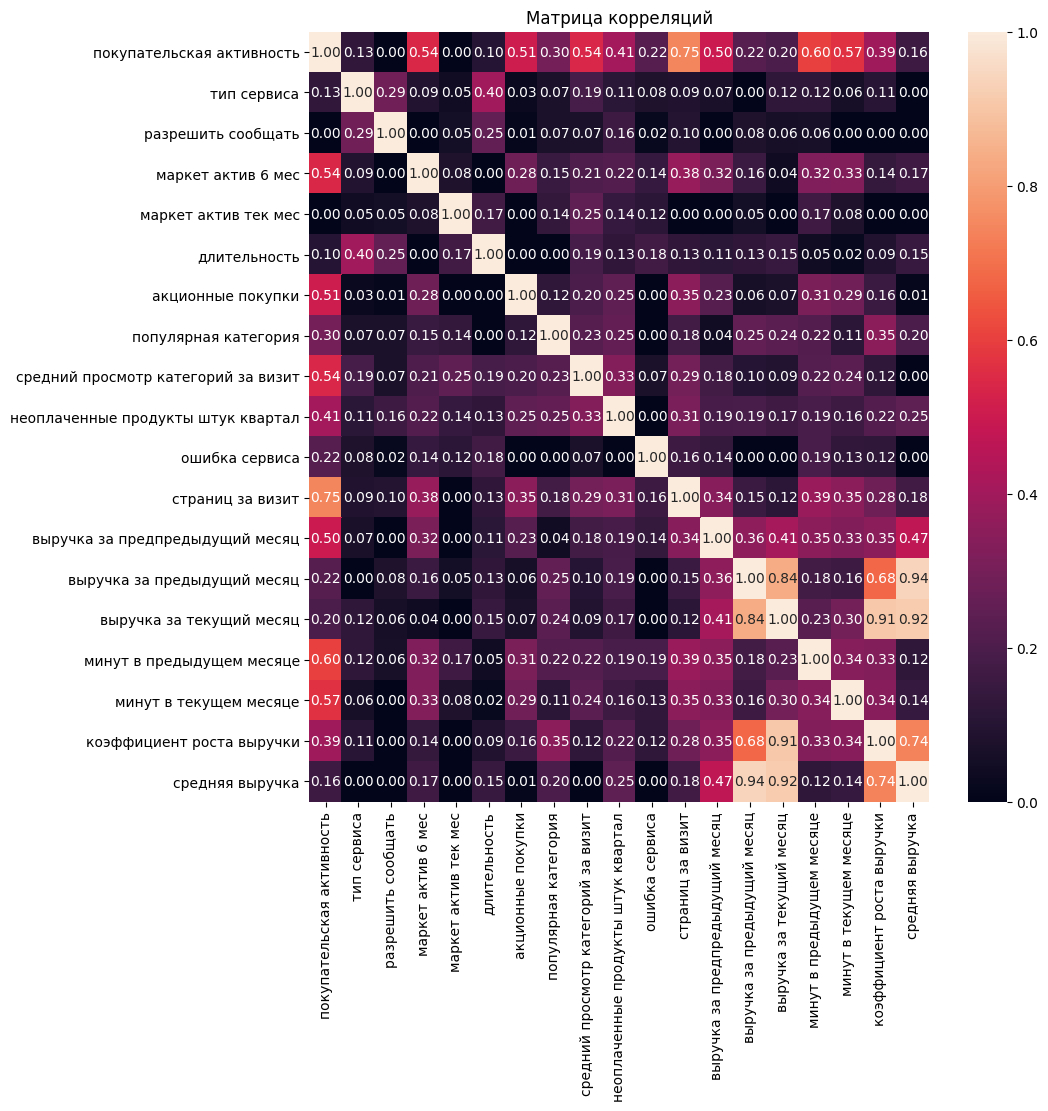

In [65]:
#Построение матрицы корреляций количественных признаков:
plt.figure(figsize=(10, 10))
sns.heatmap(
    df.phik_matrix(
        interval_cols=[
            'маркет актив 6 мес',
            'длительность',
            'акционные покупки',
            'выручка за предпредыдущий месяц',
            'выручка за предыдущий месяц',
            'выручка за текущий месяц',
            'коэффициент роста выручки',
            'средняя выручка'
            ]
        ),
    annot=True, fmt='.2f'
    )
plt.title('Матрица корреляций')
plt.show()

**Выводы Шага 5:** Проведен корреляционный анализ признаков, установлены признаки с мультиколлинеарностью, на основе них создан производный признак - средний коэффициент роста выручки, средняя выручка за весь период.

**Шаг 6.** Использование пайплайнов

In [66]:
#Задаём константу RANDOM_STATE :
RANDOM_STATE = 42

In [67]:
#Разделение выборки на тренировочную и тестовую, используем стратификацию при разделении :
X = df.drop([
    'покупательская активность',
    'выручка за предпредыдущий месяц',
    'выручка за предыдущий месяц',
    'выручка за текущий месяц'
    ],
    axis=1
    )
y = df['покупательская активность']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE  
    )

In [68]:
#Кодирование целевого признака:
print(y_train[0:9])
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)
print(y_train[0:9])

id
215858    прежний уровень
215361          снизилась
215884    прежний уровень
216564    прежний уровень
215715          снизилась
216533    прежний уровень
215674          снизилась
216334    прежний уровень
216186    прежний уровень
Name: покупательская активность, dtype: object
[0 1 0 0 1 0 1 0 0]


In [69]:
#Группируем признаки по типу необходимого преобразования :
ord_cols = [
    'тип сервиса',
    'разрешить сообщать'
    ]
ohe_cols = [  
    'популярная категория'
    ]

In [70]:
num_cols = [
    'маркет актив 6 мес',
    'длительность',
    'коэффициент роста выручки',
    'минут в предыдущем месяце',
    'минут в текущем месяце',
    'страниц за визит',
    'средний просмотр категорий за визит',
    'неоплаченные продукты штук квартал',
    'ошибка сервиса',
    'маркет актив тек мес',
    'акционные покупки',
    'средняя выручка'
    ]

In [71]:
#Создание пайплайна ohe-кодирования :
ohe_pipe = Pipeline([
    ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])
#Создание пайплайна ordinal-кодирования :
ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=[[
        'стандарт',
        'премиум'
    ],[
        'да', 'нет'
    ]], 
    handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ])
#Создание пайплайна масштабирования :
num_pipe = Pipeline([
    ('scaler', StandardScaler())
    ])
#Пайплайн преобразования данных :
data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_cols),
    ('ord', ord_pipe, ord_cols),
    ('num', num_pipe, num_cols)
    ],
    remainder='passthrough'
    )

In [72]:
#Общий пайплайн DecisionTreeClassifier :
pipe_DecisionTreeClassifier = Pipeline(
    [
    ('preprocessor', data_preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])
#Гиперпараметры DecisionTreeClassifier :
param_DecisionTreeClassifier = [
    {
    'model__max_depth': range(2, 13),
    'model__min_samples_split': range(2, 6),
    'model__min_samples_leaf': range(1, 6),
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
    }
    ]

In [73]:
#Выбираем полный перебор параметров DecisionTreeClassifier с помощью GridSearchCV.
#в качестве метрики выберем recall (нахождение true positive классов - "активность пользователя снизилась") 
#в соответствии с целями задачи.
gscv_DecisionTreeClassifier = GridSearchCV(
    pipe_DecisionTreeClassifier, 
    param_grid=param_DecisionTreeClassifier,
    cv=5,
    scoring='recall',
    n_jobs=-1
    )

In [74]:
#Обучаем класс на тренировочной выборке и подбираем лучшую модель :
gscv_DecisionTreeClassifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['популярная '
                                                                          'категория']),
                                                                        ('ord',
                                                                         Pipeline(steps=[('simpleImputer_b...
                                                                          'ошибка '
                                                                          'сервиса',
                                                                          'маркет '
                                                                          'актив '
                                                                          'тек '
                                                                          'мес',
                                                                          'акционные '
                                                                          'покупки',
                                                                          'средняя '
                                                                          'выручка'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'model__max_depth': range(2, 13),
                          'model__min_samples_leaf': range(1, 6),
                          'model__min_samples_split': range(2, 6),
                          'preprocessor__num__scaler': [StandardScaler(),
                                                        MinMaxScaler()]}],
             scoring='recall')

In [75]:
#Просмотр метрики recall лучшей модели после кросс-валидации :
print('Метрика recall лучшей модели DecisionTreeClassifier на кросс-валидации:', gscv_DecisionTreeClassifier.best_score_)

Метрика recall лучшей модели DecisionTreeClassifier на кросс-валидации: 0.7923603603603604


In [76]:
#Общий пайплайн KNeighborsClassifier :
pipe_KNeighborsClassifier = Pipeline(
    [
    ('preprocessor', data_preprocessor),
    ('model', KNeighborsClassifier())
    ])
#Гиперпараметры KNeighborsClassifier :
param_KNeighborsClassifier = [
    {
    'model__n_neighbors': range(5, 20),
    'model__metric' : ['minkowski', 'manhattan'],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
    }
    ]

In [77]:
#Выбираем полный перебор параметров KNeighborsClassifier с помощью GridSearchCV.
#в качестве метрики выберем recall (нахождение true positive классов - "активность пользователя снизилась") 
#в соответствии с целями задачи.
gscv_KNeighborsClassifier = GridSearchCV(
    pipe_KNeighborsClassifier, 
    param_grid=param_KNeighborsClassifier,
    cv=5,
    scoring='recall',
    n_jobs=-1
    )

In [78]:
#Обучаем класс на тренировочной выборке и подбираем лучшую модель :
gscv_KNeighborsClassifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['популярная '
                                                                          'категория']),
                                                                        ('ord',
                                                                         Pipeline(steps=[('simpleImputer_b...
                                                                          'визит',
                                                                          'неоплаченные '
                                                                          'продукты '
                                                                          'штук '
                                                                          'квартал',
                                                                          'ошибка '
                                                                          'сервиса',
                                                                          'маркет '
                                                                          'актив '
                                                                          'тек '
                                                                          'мес',
                                                                          'акционные '
                                                                          'покупки',
                                                                          'средняя '
                                                                          'выручка'])])),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid=[{'model__metric': ['minkowski', 'manhattan'],
                          'model__n_neighbors': range(5, 20),
                          'preprocessor__num__scaler': [StandardScaler(),
                                                        MinMaxScaler()]}],
             scoring='recall')

In [79]:
#Просмотр метрики recall лучшей модели после кросс-валидации :
print('Метрика recall лучшей модели KNeighborsClassifier на кросс-валидации:', gscv_KNeighborsClassifier.best_score_)

Метрика recall лучшей модели KNeighborsClassifier на кросс-валидации: 0.7520720720720719


In [80]:
#Общий пайплайн SVC :
pipe_SVC = Pipeline(
    [
    ('preprocessor', data_preprocessor),
    ('model', SVC(random_state=RANDOM_STATE))
    ])
#Гиперпараметры SVC :
param_SVC = [
    {
    'model__C' : range(1, 4),
    'model__degree' : range(2, 4),
    'model__kernel' : ['linear', 'sigmoid', 'rbf', 'poly'],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
    }
    ]

In [81]:
#Выбираем полный перебор параметров SVC с помощью GridSearchCV.
#в качестве метрики выберем recall (нахождение true positive классов - "активность пользователя снизилась") 
#в соответствии с целями задачи.
gscv_SVC = GridSearchCV(
    pipe_SVC,
    param_grid=param_SVC,
    cv=5,
    scoring='recall',
    n_jobs=-1
    )

In [82]:
#Обучаем класс на тренировочной выборке и подбираем лучшую модель :
gscv_SVC.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['популярная '
                                                                          'категория']),
                                                                        ('ord',
                                                                         Pipeline(steps=[('simpleImputer_b...
                                                                          'продукты '
                                                                          'штук '
                                                                          'квартал',
                                                                          'ошибка '
                                                                          'сервиса',
                                                                          'маркет '
                                                                          'актив '
                                                                          'тек '
                                                                          'мес',
                                                                          'акционные '
                                                                          'покупки',
                                                                          'средняя '
                                                                          'выручка'])])),
                                       ('model', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'model__C': range(1, 4), 'model__degree': range(2, 4),
                          'model__kernel': ['linear', 'sigmoid', 'rbf', 'poly'],
                          'preprocessor__num__scaler': [StandardScaler(),
                                                        MinMaxScaler()]}],
             scoring='recall')

In [83]:
#Просмотр метрики recall лучшей модели после кросс-валидации :
print('Метрика recall лучшей модели SVC на кросс-валидации:', gscv_SVC.best_score_)

Метрика recall лучшей модели SVC на кросс-валидации: 0.760072072072072


In [88]:
#Просмотр метрики recall лучшей модели DecisionTreeClassifier на тестовых данных :
print('Метрика recall лучшей модели DecisionTreeClassifier на тестовых данных:', recall_score(y_test, gscv_DecisionTreeClassifier.best_estimator_.predict(X_test)))

Метрика recall лучшей модели DecisionTreeClassifier на тестовых данных: 0.8130081300813008


In [89]:
#Просмотр других метрик лучшей модели :
print('Метрика accuracy лучшей модели DecisionTreeClassifier :', accuracy_score(y_test, gscv_DecisionTreeClassifier.best_estimator_.predict(X_test)))
print('Метрика precision лучшей модели DecisionTreeClassifier :', precision_score(y_test, gscv_DecisionTreeClassifier.best_estimator_.predict(X_test)))
print('Метрика roc_auc лучшей модели DecisionTreeClassifier :', roc_auc_score(y_test, gscv_DecisionTreeClassifier.best_estimator_.predict_proba(X_test)[:, 1]))

Метрика accuracy лучшей модели DecisionTreeClassifier : 0.8487654320987654
Метрика precision лучшей модели DecisionTreeClassifier : 0.7936507936507936
Метрика roc_auc лучшей модели DecisionTreeClassifier : 0.8437082878291471


### **Вывод Шага 6:** Разработаны 3 пайплайна для каждой подбираемой модели классификации, лучшую метрику recall показала\
модель **DecisionTreeClassifier** с параметрами **max_depth=12, min_samples_split=5**.\
Модель показала метрику recall на кросс-валидации : **0.79**\
На тестовой выборке : **0.81**\
А также:\
accuracy : **0.85**\
precision : **0.79**\
roc_auc : **0.84**\
Признаков переобученности у модели не выявлено.

**Шаг 7.** Анализ важности признаков

In [90]:
#Преобразование выборок с помощью пайплайна :
X_train_preprocessed = pd.DataFrame(data_preprocessor.fit_transform(X_train), columns=data_preprocessor.get_feature_names_out())
X_test_preprocessed = pd.DataFrame(data_preprocessor.transform(X_test), columns=data_preprocessor.get_feature_names_out())

In [91]:
#Cохранение модели DecisionTreeClassifier на лучших параметрах:
model = DecisionTreeClassifier(max_depth=12, min_samples_split=5, random_state=RANDOM_STATE)
#Обучение модели на преобразованной тестовой выборке :
model.fit(X_train_preprocessed, y_train)

DecisionTreeClassifier(max_depth=12, min_samples_split=5, random_state=42)

In [92]:
#Создание explainer :
background_data_summary = shap.kmeans(X_train_preprocessed, 50).data
explainer = shap.KernelExplainer(model.predict_proba, background_data_summary)

In [93]:
#Получение значений Шепли :
shap_values = explainer(X_test_preprocessed)

  0%|          | 0/324 [00:00<?, ?it/s]

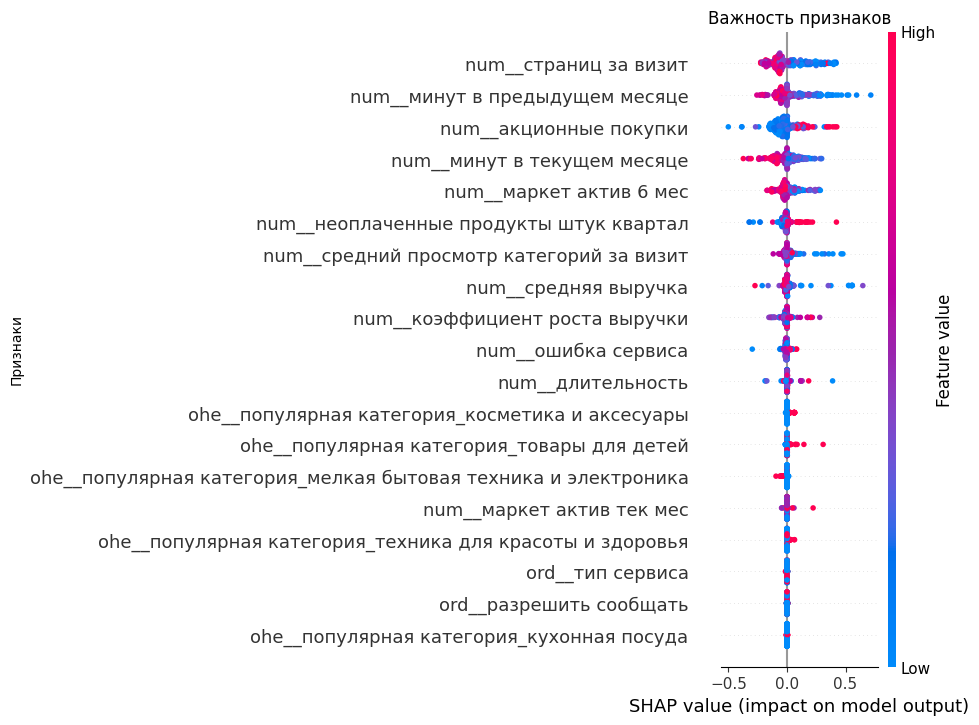

In [94]:
#Интерпретация влияния признаков на выбор модели :
shap.summary_plot(shap_values[:, :, 1], X_test_preprocessed, show=False)
fig = plt.gcf()
ax = plt.gca()
ax.set_title("Важность признаков")
ax.set_ylabel('Признаки')
fig.set_size_inches(20, 7)
plt.show()

**Выводы Шага 7:** У найденной с помощью GridSearchCV-поиска модель DecisionTreeClassifier с помощью универсального интерпретатора KernelExplainer были получены SHAP-значения входных признаков.

Наибольшее влияние на выбор модели оказывают признаки:\
***страниц за визит*** - самый важный признак, интерпретация которого показывает, что высокая активность ползователя на сайте говорит о пользователе с большой покупательской способностью.\
***минут в предыдущем месяце*** - связанный с предыдущим признак, который говорит, что активные на сайте пользоваетли также проводят на нем больше времени.\
***акционные покупки*** - большое количество акционных покупок - это принак пользователей, у которых покупательская актиность снижается.\
***минут в текущем месяце*** - признак, который говорит, что активные на сайте пользоваетли также проводят на нем больше времени.

Наимее важными являются признаки:\
***маркет актив тек мес***\
***разрешить сообщать***\
***тип сервиса***

**Шаг 8.** Сегментация покупателей

Перед сегментацией изучим замеченные аномалии во влиянии некоторых признаков на предсказания модели :

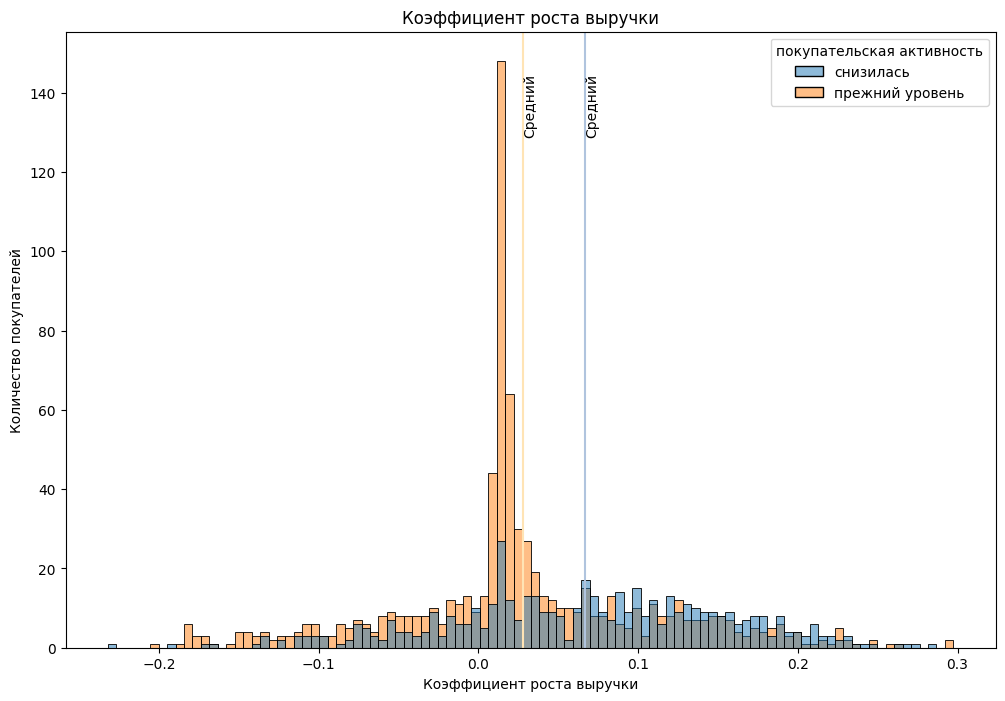

In [95]:
#Визуализация распределения покупателей по коэффициенту роста выручки с сегментацией по покупательской активности :
plt.figure(figsize=(12, 8))
ax = sns.histplot(
    x=df['коэффициент роста выручки'],
    bins=100,
    hue=df['покупательская активность'],
    )
ax.axvline(
    x=df[df['покупательская активность'] == 'прежний уровень']['коэффициент роста выручки'].mean(),
    ymin=0,
    ymax=ax.get_ylim()[1],
    color='moccasin',
    linestyle='-',
    linewidth=1.5,
    )
ax.axvline(
    x=df[df['покупательская активность'] == 'снизилась']['коэффициент роста выручки'].mean(),
    ymin=0,
    ymax=ax.get_ylim()[1],
    color='lightsteelblue',
    linestyle='-',
    linewidth=1.5,
    )
plt.text(
    x=df[df['покупательская активность'] == 'прежний уровень']['коэффициент роста выручки'].mean(),
    y=145,
    s='Средний',
    color='black',
    rotation=90,
    verticalalignment='top'
)
plt.text(
    x=df[df['покупательская активность'] == 'снизилась']['коэффициент роста выручки'].mean(),
    y=145,
    s='Средний',
    color='black',
    rotation=90,
    verticalalignment='top'
)
plt.title('Коэффициент роста выручки')
plt.xlabel('Коэффициент роста выручки')
plt.ylabel('Количество покупателей')
plt.show()

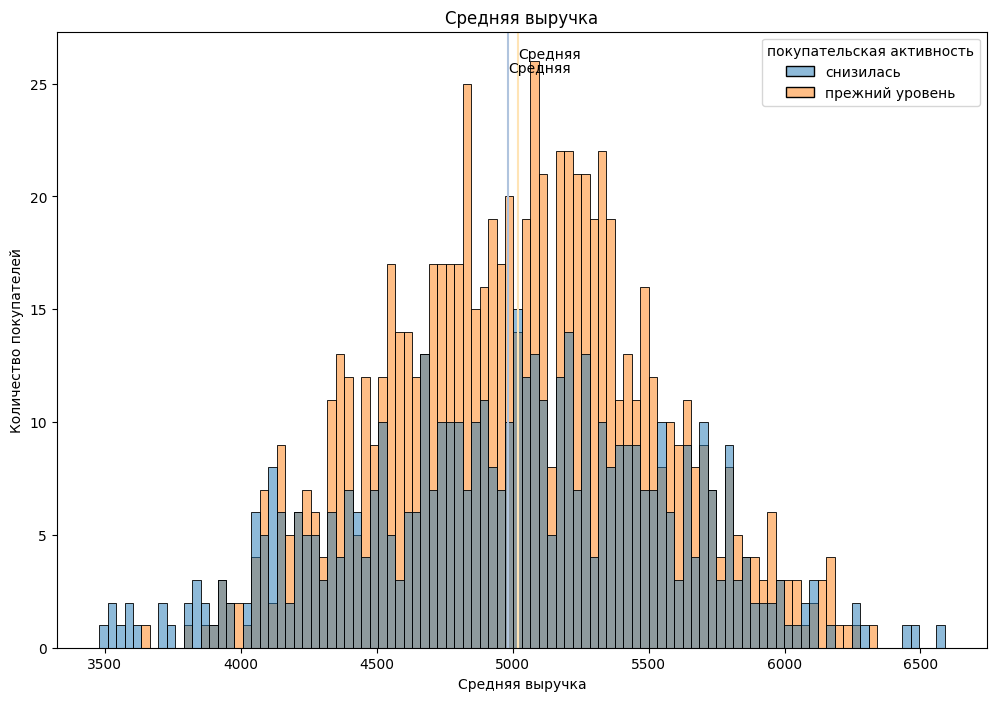

In [96]:
#Визуализация распределения покупателей по средней выручке с сегментацией по покупательской активности :
plt.figure(figsize=(12, 8))
ax = sns.histplot(
    x=df['средняя выручка'],
    bins=100,
    hue=df['покупательская активность'],
    )
ax.axvline(
    x=df[df['покупательская активность'] == 'прежний уровень']['средняя выручка'].mean(),
    ymin=0,
    ymax=ax.get_ylim()[1],
    color='moccasin',
    linestyle='-',
    linewidth=1.5,
    )
ax.axvline(
    x=df[df['покупательская активность'] == 'снизилась']['средняя выручка'].mean(),
    ymin=0,
    ymax=ax.get_ylim()[1],
    color='lightsteelblue',
    linestyle='-',
    linewidth=1.5,
    )
plt.text(
    x=df[df['покупательская активность'] == 'прежний уровень']['средняя выручка'].mean(),
    y=26,
    s='Средняя',
    color='black',
    rotation=0,
    verticalalignment='bottom'
)
plt.text(
    x=df[df['покупательская активность'] == 'снизилась']['средняя выручка'].mean(),
    y=26,
    s='Средняя',
    color='black',
    rotation=0,
    verticalalignment='top'
)
plt.title('Средняя выручка')
plt.xlabel('Средняя выручка')
plt.ylabel('Количество покупателей')
plt.show()

Так как популярная категория товара является важным признаком для принятия решения моделью KNeighborsClassifier, выполним сегментацию по этому признаку и выберем сегмент для изучения.

In [97]:
#Сгруппируем покупателей по популятным категориям покупок и получим средние значения признаков :
df_popular_cats = df.pivot_table(
    index=['популярная категория', 'тип сервиса'],
    values=['средняя выручка', 'коэффициент роста выручки', 'маркет актив 6 мес', 'акционные покупки'],
    aggfunc='mean'
    )
df_popular_cats = df_popular_cats.round(2)
df_popular_cats = df_popular_cats.reset_index()

In [98]:
df_popular_cats

,популярная категория,тип сервиса,акционные покупки,коэффициент роста выручки,маркет актив 6 мес,средняя выручка
0,домашний текстиль,премиум,0.29,0.06,4.23,5166.70
1,домашний текстиль,стандарт,0.30,0.05,4.20,5076.09
2,косметика и аксесуары,премиум,0.33,0.07,4.03,5115.49
3,косметика и аксесуары,стандарт,0.34,0.05,4.31,5091.36
4,кухонная посуда,премиум,0.37,0.07,3.95,5239.86
5,кухонная посуда,стандарт,0.36,0.07,4.14,5174.88
6,мелкая бытовая техника и электроника,премиум,0.30,0.03,4.50,5060.73
7,мелкая бытовая техника и электроника,стандарт,0.26,0.04,4.57,5069.28
8,техника для красоты и здоровья,премиум,0.33,0.01,4.22,4719.32
9,техника для красоты и здоровья,стандарт,0.31,0.03,4.39,4860.29


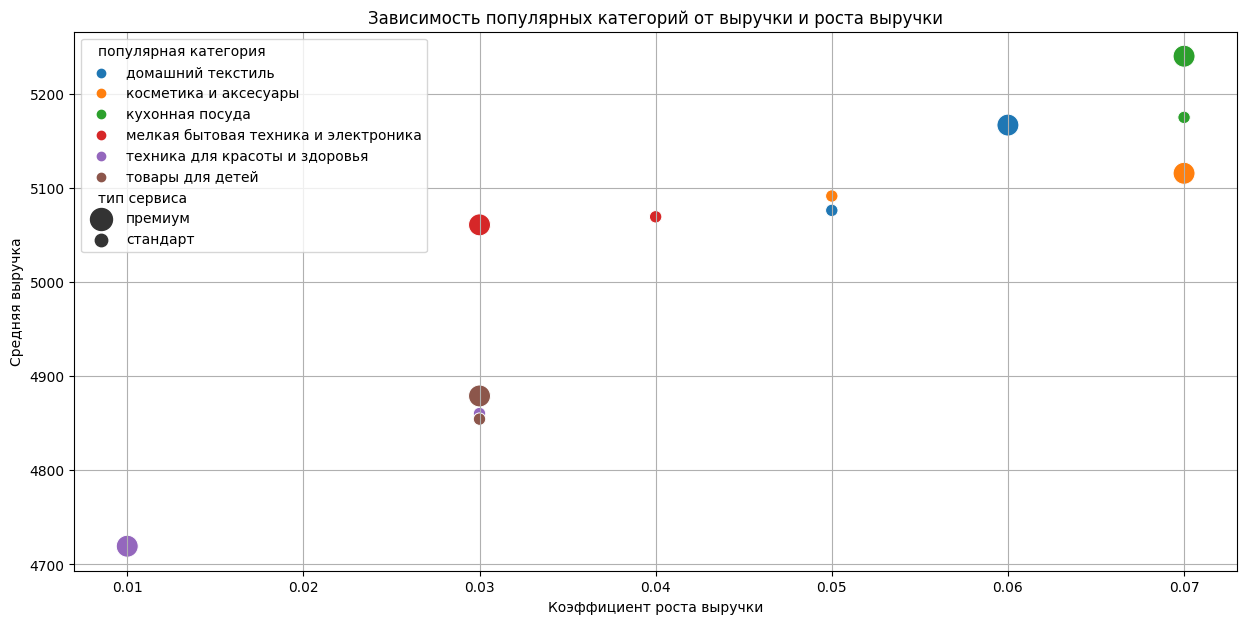

In [99]:
#Визуализация зависимости популярных категорий от выручки и роста выручки стандартного сервиса :
plt.figure(figsize=(15, 7))
sns.scatterplot(
    x=df_popular_cats['коэффициент роста выручки'],
    y=df_popular_cats['средняя выручка'],
    hue=df_popular_cats['популярная категория'],
    size=df_popular_cats['тип сервиса'],
    sizes=(80, 250)
    )
plt.title('Зависимость популярных категорий от выручки и роста выручки')
plt.xlabel('Коэффициент роста выручки')
plt.ylabel('Средняя выручка')
plt.grid()
plt.show()

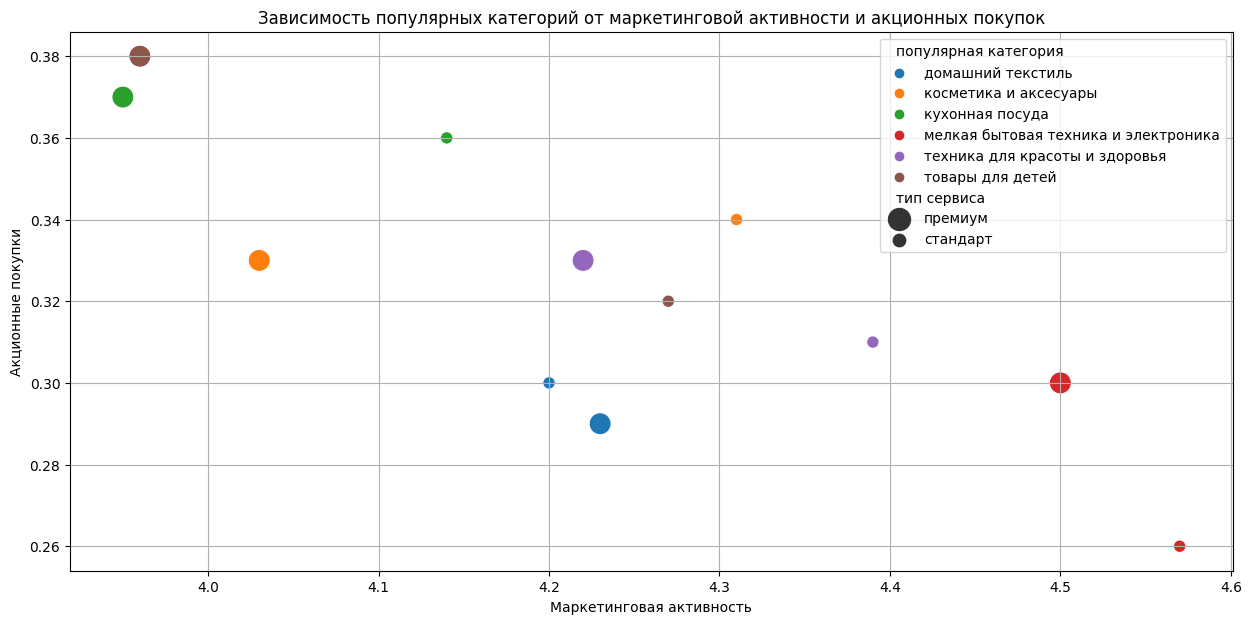

In [100]:
#Визуализация зависимости популярных категорий от маркетинговой активности и акционных покупок :
plt.figure(figsize=(15, 7))
sns.scatterplot(
    x=df_popular_cats['маркет актив 6 мес'],
    y=df_popular_cats['акционные покупки'],
    hue=df_popular_cats['популярная категория'],
    size=df_popular_cats['тип сервиса'],
    sizes=(80, 250)
    )
plt.title('Зависимость популярных категорий от маркетинговой активности и акционных покупок')
plt.xlabel('Маркетинговая активность')
plt.ylabel('Акционные покупки')
plt.grid()
plt.show()

In [101]:
#Выберем целевой сегмент - "техника для красоты и здоровья" и получим описательную статистику этого сегмента :
means1 = df_popular_cats[df_popular_cats['популярная категория'] == 'техника для красоты и здоровья'].mean()
means2 = df_popular_cats.mean()

In [102]:
#Разница показателей категории со средними показателями :
means1 - means2

акционные покупки             -0.004167
коэффициент роста выручки     -0.025000
маркет актив 6 мес             0.074167
средняя выручка             -235.802500
dtype: float64

In [103]:
median1 = df_popular_cats[df_popular_cats['популярная категория'] == 'техника для красоты и здоровья'].median()
median2 = df_popular_cats.median()

In [104]:
#Разница показателей категории с медианными показателями :
median1 - median2

акционные покупки             -0.005
коэффициент роста выручки     -0.025
маркет актив 6 мес             0.080
средняя выручка             -282.880
dtype: float64

In [105]:
df[df['популярная категория'] == 'техника для красоты и здоровья']['покупательская активность'].value_counts()

прежний уровень    132
снизилась           50
Name: покупательская активность, dtype: int64

**Вывод Шага 8:** Перед сегментацией пользователей проведено сравнение распределений пользователей по коэффициенту роста выручки, по результатам которого установлена странная закономерность - пользователи, у которых покупательская активность снизилась, за рассматриваемый период имели более высокий коэффициент роста выручки, чем у пользователей с покупательской активностью на прежнем уровне.\
Исследована описательная статистика популярных категорий товаров, из который выран сегмент покупателей "техника для красоты и здоровья".

Этот сегмент пользователей харатеризуется тем, что такие пользователи:
- принесли меньше всего выручки (на 236 меньше средней и на 282 меньше медианной выручки)
- пользователи совершали на 0.004 меньше средней и на 0.005 меньше медианной доле акционных покупок
- маркетинговая активность на одного пользователя была выше среднего
- рост выручки пользователей был самый низкий (на 0.025 меньше среднего медианного коэффициента роста выручки)
- из 182 покупателей этой популярной категории снизили покупательскую активность 50 пользователей.

Рекомендации бизнесу: пользователи популярной категории "техника для красоты и здоровья" принесли меньше всего выручки, и при этом совершали мало акционных покупок, а маркетинговая активность в отношении них была на среднем уровне. Для таких пользователей можно расширить акционный ассортимент товаров. В исследовательском анализе было установлено, что покупателей техники для красоты и здоровья всего 13.4% от общего количества пользователей, поэтому компании имеет смысл привлечь новых покупателей дополнительными маркетинговыми акциями, так как текущая маркетинговая активность по этому сегменту невысокая и это не создаст чрезмерных затрат. Для этих целей можно использовать ранее разработанную модель KNeighborsClassifier с высокой метрикой precision, которая эффективно будет указывать пользователей, которые, скорее всего, снизят активность и для которых проведение маркетинговых акций наиболее выгодно.



**Шаг 9.** Общий вывод

### Данные успешно загружены, просмотрены, предварительно намечены задачи предобработки.

Данные предобработаны, приведены к однообразному форматированию, дубликаты удалены, пропуски проверены.

Проведен исследовательский анализ данных, визуализированы количественные и категориальные признаки, получена описательная статистика. В большинстве случаев распределение количестенных признаков близко к нормальному. Аномальные значения удалены. Отобраны пользователи с покупательской активностью на протяжении всех трёх месяцев. В целевом признаке наблюдается дисбаланс классов в соотношении 1 к 2.

Проведен корреляционный анализ признаков, установлены признаки с мультиколлинеарностью, на основе них создан производный признак - средний коэффициент роста выручки, средняя выручка за весь период.

Разработаны 3 пайплайна для каждой подбираемой модели классификации, лучшую метрику recall показала\
модель **DecisionTreeClassifier** с параметрами **max_depth=12, min_samples_split=5**.\
Модель показала метрику recall на кросс-валидации : **0.79**\
На тестовой выборке : **0.81**\
А также:\
accuracy : **0.85**\
precision : **0.79**\
roc_auc : **0.84**\
Признаков переобученности у модели не выявлено.

У найденной с помощью GridSearchCV-поиска модель DecisionTreeClassifier с помощью универсального интерпретатора KernelExplainer были получены SHAP-значения входных признаков.

Наибольшее влияние на выбор модели оказывают признаки:\
***страниц за визит*** - самый важный признак, интерпретация которого показывает, что высокая активность ползователя на сайте говорит о пользователе с большой покупательской способностью.\
***минут в предыдущем месяце*** - связанный с предыдущим признак, который говорит, что активные на сайте пользоваетли также проводят на нем больше времени.\
***акционные покупки*** - большое количество акционных покупок - это принак пользователей, у которых покупательская актиность снижается.\
***минут в текущем месяце*** - признак, который говорит, что активные на сайте пользоваетли также проводят на нем больше времени.

Наимее важными являются признаки:\
***маркет актив тек мес***\
***разрешить сообщать***\
***тип сервиса***

Перед сегментацией пользователей проведено сравнение распределений пользователей по коэффициенту роста выручки, по результатам которого установлена странная закономерность - пользователи, у которых покупательская активность снизилась, за рассматриваемый период имели более высокий коэффициент роста выручки, чем у пользователей с покупательской активностью на прежнем уровне.\
Исследована описательная статистика популярных категорий товаров, из который выран сегмент покупателей "техника для красоты и здоровья".

Этот сегмент пользователей харатеризуется тем, что такие пользователи:
- принесли меньше всего выручки (на 236 меньше средней и на 282 меньше медианной выручки)
- пользователи совершали на 0.004 меньше средней и на 0.005 меньше медианной доле акционных покупок
- маркетинговая активность на одного пользователя была выше среднего
- рост выручки пользователей был самый низкий (на 0.025 меньше среднего медианного коэффициента роста выручки)
- из 182 покупателей этой популярной категории снизили покупательскую активность 50 пользователей.

Рекомендации бизнесу: пользователи популярной категории "техника для красоты и здоровья" принесли меньше всего выручки, и при этом совершали мало акционных покупок, а маркетинговая активность в отношении них была на среднем уровне. Для таких пользователей можно расширить акционный ассортимент товаров. В исследовательском анализе было установлено, что покупателей техники для красоты и здоровья всего 13.4% от общего количества пользователей, поэтому компании имеет смысл привлечь новых покупателей дополнительными маркетинговыми акциями, так как текущая маркетинговая активность по этому сегменту невысокая и это не создаст чрезмерных затрат. Для этих целей можно использовать ранее разработанную модель DecisionTreeClassifier с высокой метрикой recall, которая эффективно будет указывать пользователей, которые, скорее всего, снизят активность и для которых проведение маркетинговых акций наиболее выгодно.

https://github.com/Sergey7492git/first-project.git